In [ ]:
from pathlib import Path

from aroma import load_geometry
from aroma.connectivity import adjacency_list, bond_matrix
from aroma.rings import find_rings
from aroma.nics import run_nics_scan
from aroma.backend.pyscf_nmr import PyscfNmrBackend

/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/efg/rhf.py:45: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/efg/dhf.py:30: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/zfs/uhf.py:40: UserWarning: Module ZFS is under testing
  warnings.warn('Module ZFS is under testing')
/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/gtensor/uhf.py:43: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/gtensor/uks.py:41: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/Users/sam/Programs/aroma/.venv/lib/python3.9/site-packages/pyscf/prop/hfc/uks.py:35: UserWarning: Mod

In [3]:
benzene_data = Path("../tests/data/benzene/benzene.in")
benzene_mol = load_geometry(benzene_data)
ring = find_rings(adjacency_list(bond_matrix(benzene_mol)))[0]
result = run_nics_scan(benzene_mol, ring, PyscfNmrBackend(method="b3lyp", basis="6-311+g*"))
print(result.distances, result.nics_iso, result.nics_zz)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4. ] [ -7.67924941  -7.72033825  -7.96995075  -8.3758202   -8.86208424
  -9.34649194  -9.75600805 -10.03715902 -10.1600715  -10.11722427
  -9.91889659  -9.58730416  -9.1509125   -8.63978845  -8.08231082
  -7.50319263  -6.92257155  -6.35586364  -5.81409826  -5.30451115
  -4.83123844  -4.39600983  -3.99878138  -3.6382773   -3.31243019
  -3.01872171  -2.75443382  -2.51682436  -2.30324212  -2.11119624
  -1.93839235  -1.78274616  -1.64238252  -1.51562566  -1.40098492
  -1.29713828  -1.2029157   -1.11728284  -1.03932591  -0.96823776
  -0.90330526] [-13.70069119 -13.96374738 -15.11705232 -16.97562034 -19.26565277
 -21.6823198  -23.94507855 -25.83716971 -27.2237412  -28.05047497
 -28.32903951 -28.1167079  -27.49608356 -26.55849466 -25.39237314
 -24.07638474 -22.67630229 -21.24442958 -19.82053125 -18.43349691
 -17.10323726 -15.8425235

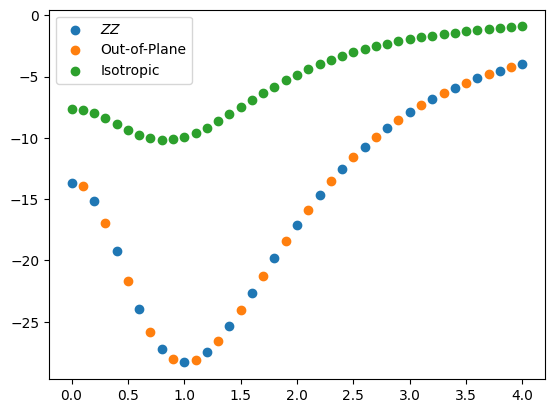

In [ ]:
import matplotlib.pyplot as plt

# plot results
fig, ax = plt.subplots()

# Isotropic (average of XX, YY, ZZ components of chemical shift tensor)
ax.scatter(result.distances, result.nics_iso, label=r"Isotropic")

# ZZ and Out-of-plane (oop) identical (component of chemical shift in direction normal to plane of ring)
# plot every other to show that they're the same
ax.scatter(result.distances[::2], result.nics_zz[::2], label=r"$ZZ$")
ax.scatter(result.distances[1::2], result.nics_oop[1::2], label=r"Out-of-Plane")

ax.legend()